In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import load_from_disk
import numpy as np
import evaluate

print("1. Loading dataset...")
dataset_train = load_from_disk("dataset_asli_finetune/train")
dataset_test = load_from_disk("dataset_asli_finetune/test")

dataset_train = dataset_train.rename_column("Label", "label")
dataset_test = dataset_test.rename_column("Label", "label")

print("2. Loading IndoBERT model...")
model = AutoModelForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=2)

print("3. Setting up target metric (F1 Score)...")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric_f1.compute(predictions=predictions, references=labels, average="macro")

print("4. Setting up AI training parameters...")
training_args = TrainingArguments(
    output_dir="./hasil_finetuning",
    eval_strategy="epoch",       
    save_strategy="epoch",       
    learning_rate=2e-5,          
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    fp16=True,
    num_train_epochs=3,          
    weight_decay=0.01,
    logging_dir='./logs_asli',
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_train,
    eval_dataset=dataset_test,
    compute_metrics=compute_metrics,
)

print("5. Starting to train Semarangan data")
trainer.train()

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Loading dataset...
2. Loading IndoBERT model...


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 25684.42it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


3. Setting up target metric (F1 Score)...


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


4. Setting up AI training parameters...
5. Starting to train Semarangan data


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1
1,No log,0.129171,0.975692
2,0.576736,0.131149,0.980902
3,0.576736,0.120752,0.982639


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.22it/s]
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.91it/s]


TrainOutput(global_step=864, training_loss=0.3628883847483882, metrics={'train_runtime': 2718.4457, 'train_samples_per_second': 2.539, 'train_steps_per_second': 0.318, 'total_flos': 454063903787520.0, 'train_loss': 0.3628883847483882, 'epoch': 3.0})

In [2]:
from transformers import pipeline, AutoTokenizer

print("1. Preparing the detection tool...")
# Recalling the IndoBERT tokenizer dictionary
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

# Creating the detector linked to your trained model
# device=0 means we are forcing this process to use your RTX 4060 power for instant results
detector = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

# Function to format the AI's predictions
def check_comment(text):
    result = detector(text)[0]
    # Converting machine code (LABEL_0 / LABEL_1) into human language
    category = "🚨 BULLYING (Harsh/Toxic)" if result['label'] == 'LABEL_1' else "😂 JOKE (Safe/Kidding)"
    confidence = result['score'] * 100
    
    print(f"Comment    : \"{text}\"")
    print(f"Prediction : {category} (Confidence: {confidence:.2f}%)")
    print("-" * 60)

print("2. STARTING THE TEST!\n")

# --- FEEL FREE TO CHANGE OR ADD SENTENCES BELOW AS YOU LIKE ---

check_comment("Muka lu jelek banget sumpah, jijik gue liatnya, mending minggat aja lu!")
check_comment("kameramen minggir dulu lah ege😭😭")
check_comment("Cah semarang nek guyon emang kasar, tapi asline apik kok.")
check_comment("Dasar anak pungut, otak udang gak berguna di kelas.")
check_comment("Piye kabare ndes? Sido nongkrong ning burjo biasane ra?")

1. Preparing the detection tool...
2. STARTING THE TEST!

Comment    : "Muka lu jelek banget sumpah, jijik gue liatnya, mending minggat aja lu!"
Prediction : 🚨 BULLYING (Harsh/Toxic) (Confidence: 100.00%)
------------------------------------------------------------
Comment    : "kameramen minggir dulu lah ege😭😭"
Prediction : 😂 JOKE (Safe/Kidding) (Confidence: 99.89%)
------------------------------------------------------------
Comment    : "Cah semarang nek guyon emang kasar, tapi asline apik kok."
Prediction : 😂 JOKE (Safe/Kidding) (Confidence: 100.00%)
------------------------------------------------------------
Comment    : "Dasar anak pungut, otak udang gak berguna di kelas."
Prediction : 🚨 BULLYING (Harsh/Toxic) (Confidence: 100.00%)
------------------------------------------------------------
Comment    : "Piye kabare ndes? Sido nongkrong ning burjo biasane ra?"
Prediction : 😂 JOKE (Safe/Kidding) (Confidence: 100.00%)
------------------------------------------------------------


In [3]:
# Menyimpan model dan kamus bahasanya ke folder khusus untuk Web
trainer.save_model("./model_IndoBERT_BatasKata")
tokenizer.save_pretrained("./model_IndoBERT_BatasKata")

print("Model save to new folder 'model_IndoBERT_BatasKata'")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.82it/s]

Model save to new folder 'model_IndoBERT_BatasKata'


Reading AI log history...
System detected metric: F1


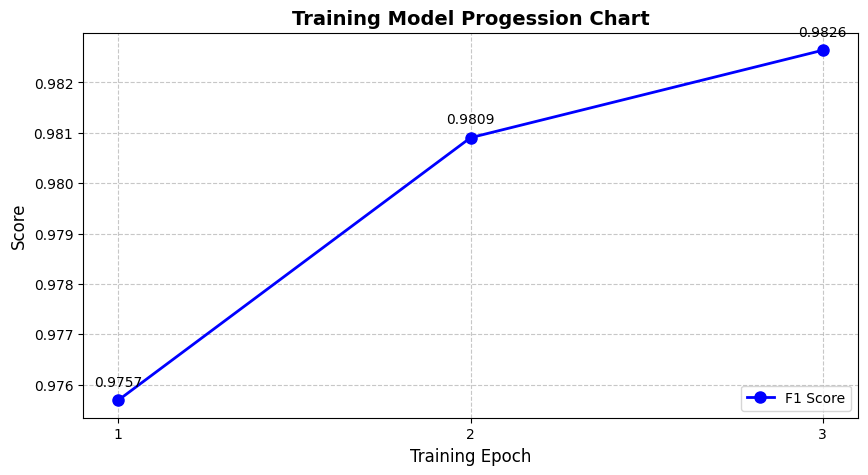

Chart successfully created and saved!


In [4]:
import matplotlib.pyplot as plt

print("Reading AI log history...")
log_history = trainer.state.log_history

epochs = []
test_scores = []

# 1. Auto-Detect: Check if AI recorded F1 or Accuracy
score_key = 'eval_f1'
if not any('eval_f1' in log for log in log_history):
    if any('eval_accuracy' in log for log in log_history):
        score_key = 'eval_accuracy'
    else:
        print("Oops, F1 or Accuracy value not found in logs!")

print(f"System detected metric: {score_key.replace('eval_', '').upper()}")

# 2. Extracting numbers from logs in pairs to ensure balance
for log in log_history:
    if score_key in log and 'epoch' in log:
        epochs.append(log['epoch'])
        test_scores.append(log[score_key])

# 3. DRAWING THE CHART (If data is safe/available)
if len(epochs) == 0 or len(test_scores) == 0:
    print("Failed to draw: Data is empty. Make sure you have run 'trainer.train()' to completion.")
else:
    plt.figure(figsize=(10, 5))

    # Chart Line
    chart_label = f"{score_key.replace('eval_', '').upper()} Score"
    plt.plot(epochs, test_scores, marker='o', linestyle='-', color='b', linewidth=2, markersize=8, label=chart_label)

    # Chart Decorations
    plt.title('Training Model Progession Chart', fontsize=14, fontweight='bold')
    plt.xlabel('Training Epoch', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.xticks(epochs) 
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')

    # Attaching numbers to the data points
    for i, txt in enumerate(test_scores):
        plt.annotate(f"{txt:.4f}", (epochs[i], test_scores[i]), textcoords="offset points", xytext=(0,10), ha='center')

    # Saving and Showing the Chart
    plt.savefig("Model_Progression_Chart.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Chart successfully created and saved!")

1. Running AI evaluation on test data...


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2. Calculating error and accuracy rates...


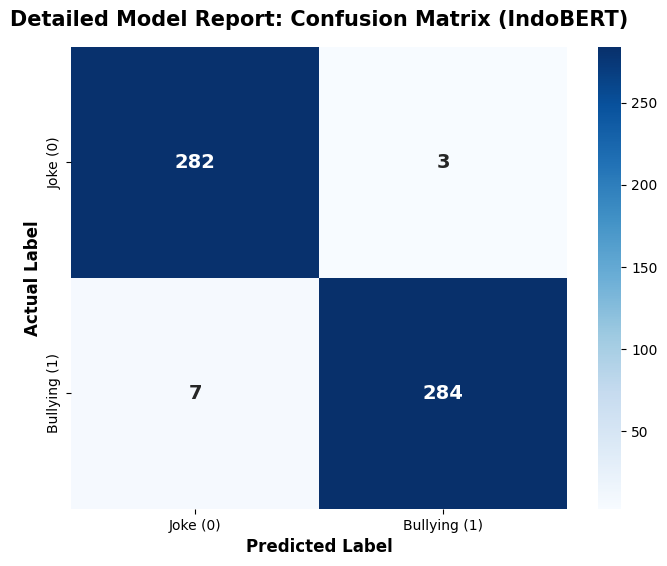

Perfect! Matrix image saved as 'Confusion_Matrix_Chart.png'


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("1. Running AI evaluation on test data...")
test_results = trainer.predict(dataset_test)

# Extracting AI predictions and actual answer keys
ai_predictions = np.argmax(test_results.predictions, axis=-1)
actual_labels = test_results.label_ids

print("2. Calculating error and accuracy rates...")
cm = confusion_matrix(actual_labels, ai_predictions)

# DRAWING THE CONFUSION MATRIX
plt.figure(figsize=(8, 6))
# Create an aesthetic blue heatmap (Darker color means more data)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=['Joke (0)', 'Bullying (1)'], 
            yticklabels=['Joke (0)', 'Bullying (1)'])

# Chart Decorations
plt.title('Detailed Model Report: Confusion Matrix (IndoBERT)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')

# Saving and Showing the Chart
plt.savefig("Confusion_Matrix_Chart.png", dpi=300, bbox_inches='tight')
plt.show()

print("Perfect! Matrix image saved as 'Confusion_Matrix_Chart.png'")

Reading AI log history for Learning Curve...


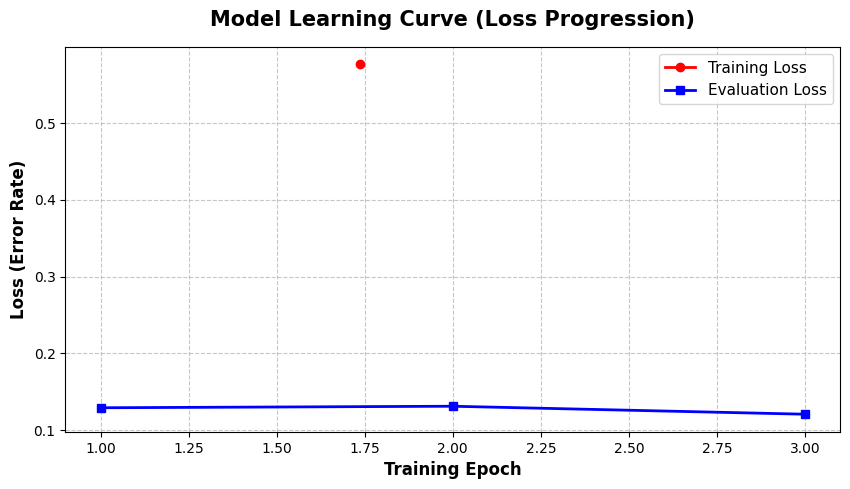

Learning Curve successfully created and saved as 'Learning_Curve_Chart.png'


In [6]:
import matplotlib.pyplot as plt

print("Reading AI log history for Learning Curve...")
log_history = trainer.state.log_history

train_epochs = []
train_losses = []
eval_epochs = []
eval_losses = []

# 1. Extracting Loss values from logs
for log in log_history:
    # Get Training Loss
    if 'loss' in log and 'epoch' in log:
        train_epochs.append(log['epoch'])
        train_losses.append(log['loss'])
    
    # Get Evaluation Loss
    if 'eval_loss' in log and 'epoch' in log:
        eval_epochs.append(log['epoch'])
        eval_losses.append(log['eval_loss'])

# 2. DRAWING THE LEARNING CURVE
if len(train_losses) == 0 and len(eval_losses) == 0:
    print("Failed to draw: Data is empty. Make sure you have run 'trainer.train()' to completion.")
else:
    plt.figure(figsize=(10, 5))

    # Plotting Training Loss (Red Line)
    if len(train_losses) > 0:
        plt.plot(train_epochs, train_losses, marker='o', linestyle='-', color='red', linewidth=2, markersize=6, label='Training Loss')
    
    # Plotting Evaluation Loss (Blue Line)
    if len(eval_losses) > 0:
        plt.plot(eval_epochs, eval_losses, marker='s', linestyle='-', color='blue', linewidth=2, markersize=6, label='Evaluation Loss')

    # Chart Decorations
    plt.title('Model Learning Curve (Loss Progression)', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Training Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Loss (Error Rate)', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='upper right', fontsize=11)

    # Saving and Showing the Chart
    plt.savefig("Learning_Curve_Chart.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("Learning Curve successfully created and saved as 'Learning_Curve_Chart.png'")